In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.datasets.mos2_sr import BTOSRDataset
from src.models.our_method.swin_cafm import SwinCAFM
from src.util.metrics import RMSE_surface_roughness_l1
from src.util.material_property_eval import calculate_roughness
from src.util.moment_based import calc_moment_based_stats

### Load Model + Dataset

In [9]:
MODEL_FP        = "/playpen/mufan/levi/tianlong-chen-lab/sparse-cafm/__exps__/bto/2025-06-05_10-39-32_long-run-moment-based-stats/best_epoch_30.pth"
dataset         = BTOSRDataset(split="val", upsample_factor=4)
model: SwinCAFM = torch.load(MODEL_FP).cuda();

/tmp/ipykernel_2337129/2438558780.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: SwinCAFM = torch.load(MODEL_FP).cuda();


In [10]:
FOUR_X_FP = "data/raw-data/5-15-25/Sample A2 scan 128 02-05-2025_250502_Z Height_Backward_003.npy"

# load [64, 64] validation sample
sparse_data = np.load(FOUR_X_FP)
sparse_data = torch.Tensor(sparse_data)
sparse_sr   = calculate_roughness((sparse_data))

### Predict

In [11]:
# -> normalize to nn distribution: [0, 1]
X = sparse_data.clone()
X = (X - dataset.topo_maps_min) / (dataset.topo_maps_max - dataset.topo_maps_min)

# X_hat
pred = model(X.cuda().unsqueeze(0))

# -> scale original topology map distribution (nm)f
pred_orig = (
    pred * (dataset.topo_maps_max - dataset.topo_maps_min) + dataset.topo_maps_min
)
pred_orig_np = pred_orig.squeeze(0).detach().cpu().numpy()

# get surface roughness
predicted_sr = calculate_roughness(pred_orig_np)

In [12]:
# get the original, full-resolution topology map
gt = np.load("data/raw-data/3-12-25/A4 512_Z Height_Backward_011.npy")

# get surface roughness
ground_truth_sr = calculate_roughness(gt)

### Generate Figure

/tmp/ipykernel_2337129/1748844612.py:19: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  tensors = np.array([sparse_data, pred_orig_np])
/tmp/ipykernel_2337129/1748844612.py:19: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  tensors = np.array([sparse_data, pred_orig_np])


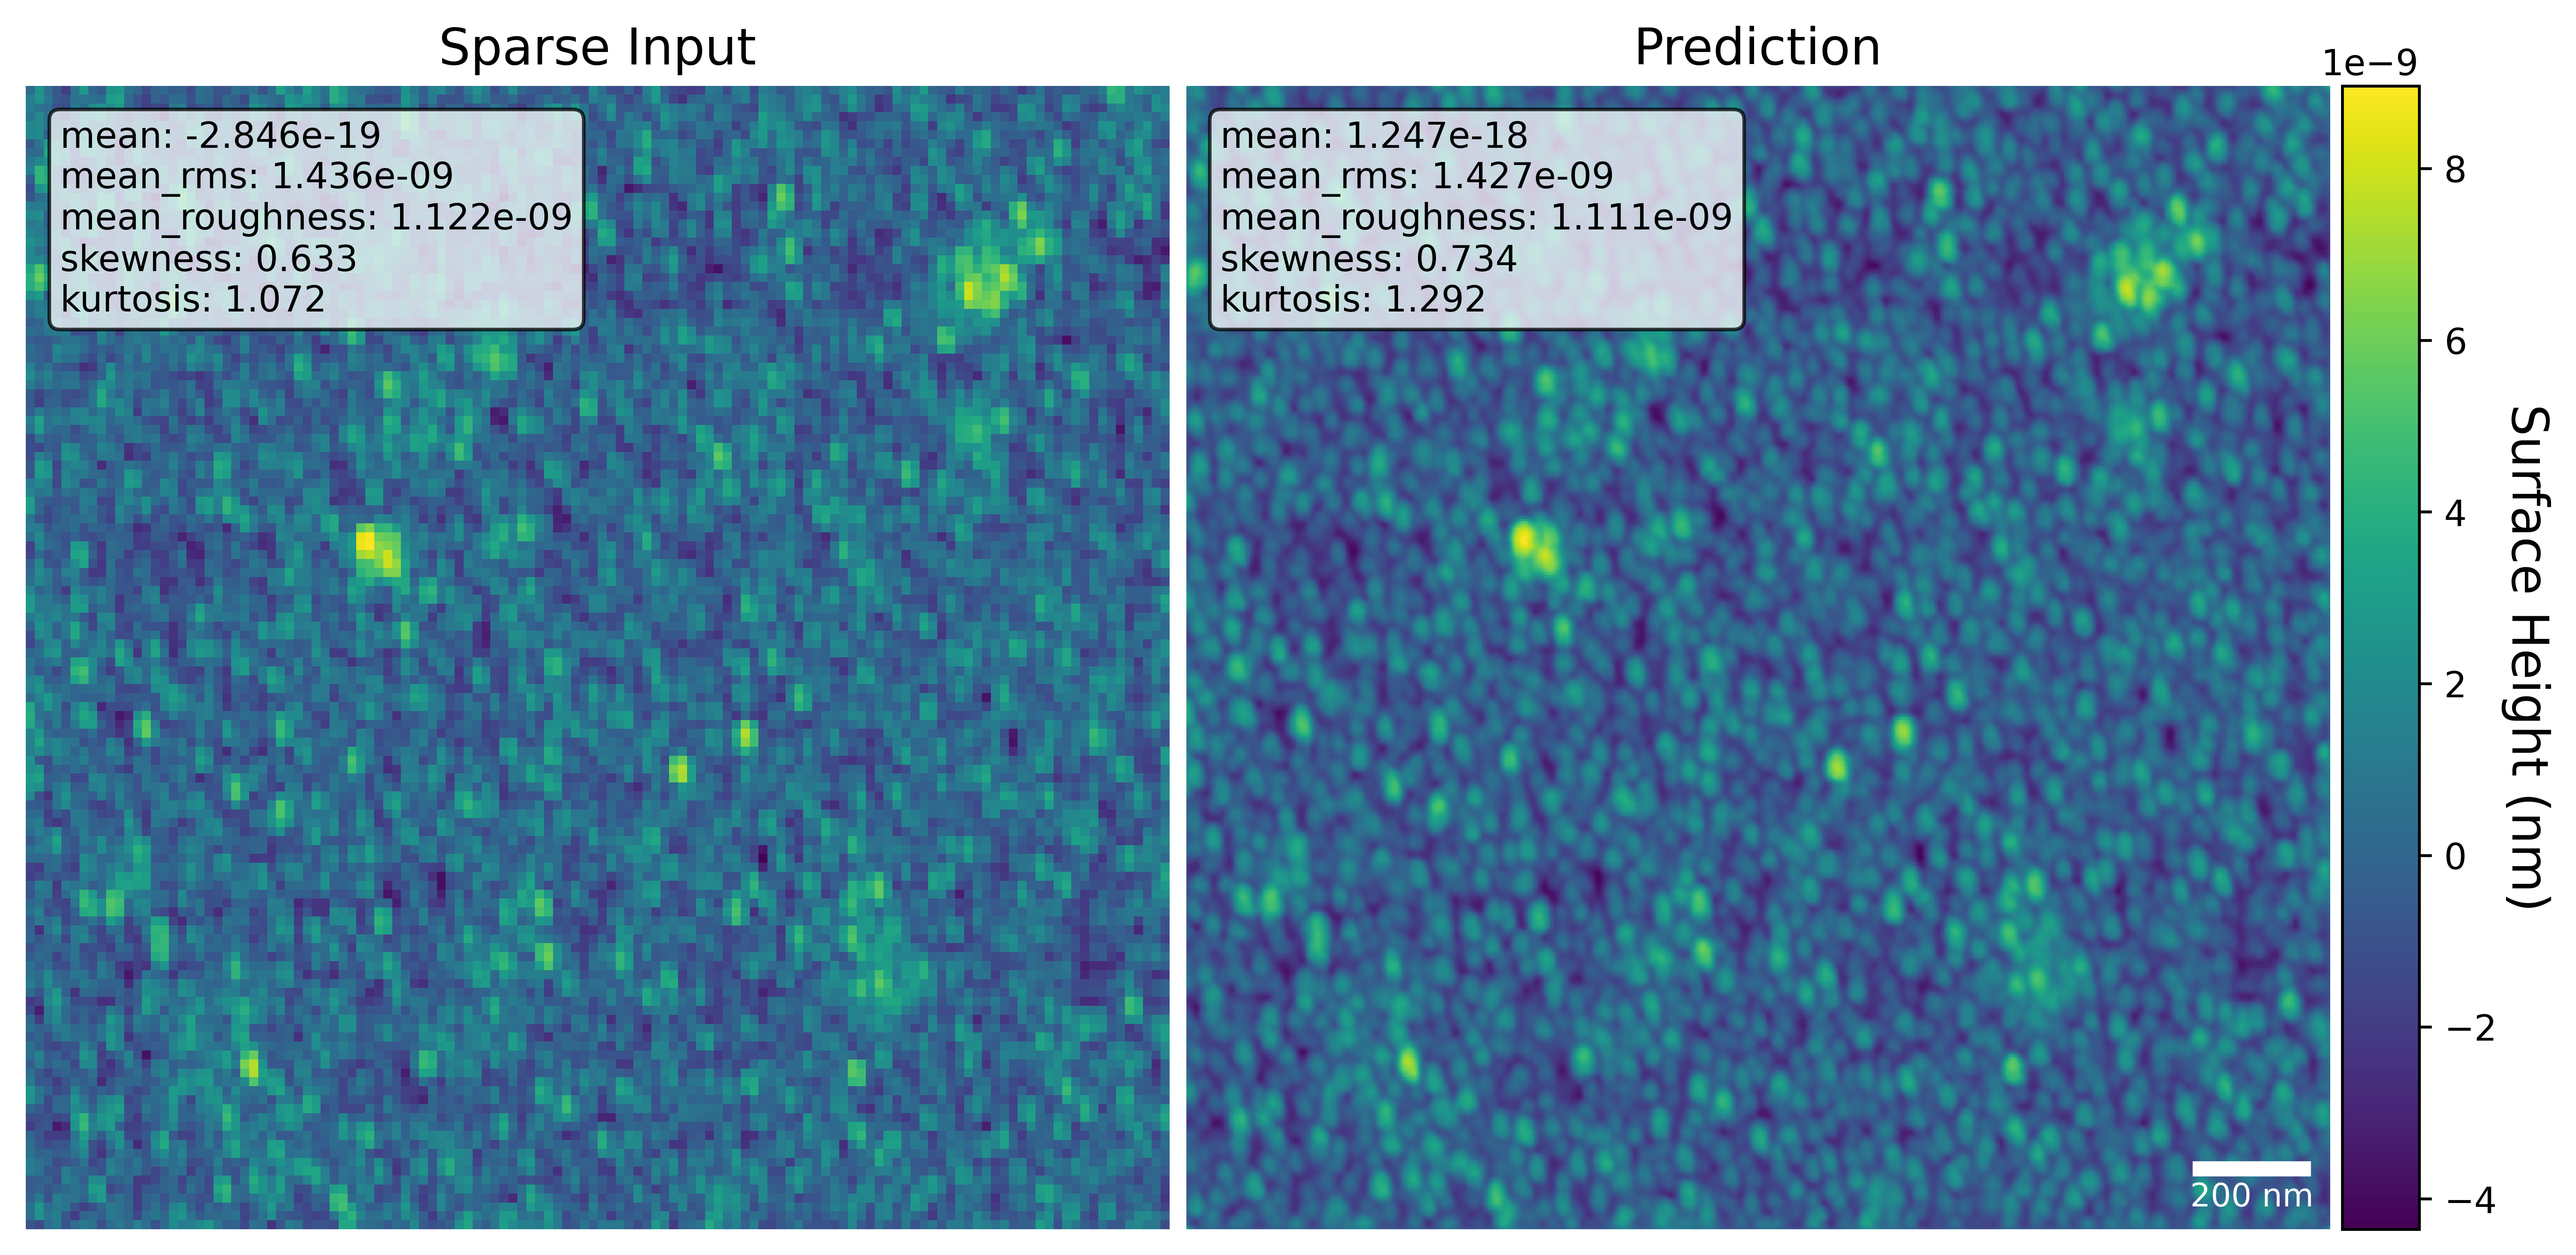

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar


fig = plt.figure(figsize=(12, 5.76), dpi=600)
width_ratios = [15, 15, 1]
gs = gridspec.GridSpec(1, 3, width_ratios=width_ratios, wspace=0.01)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

image_axes = [ax1, ax2]
tensors = np.array([sparse_data, pred_orig_np])
titles = ["Sparse Input", "Prediction"]

# calcualte the moment-based stats; list of dicts
stats = [calc_moment_based_stats(torch.Tensor(sparse_data).unsqueeze(0)), calc_moment_based_stats(torch.Tensor(pred_orig_np).unsqueeze(0))]

im = None
for i, (ax, tensor, title) in enumerate(zip(image_axes, tensors, titles)):

    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="lightgrey")
    current_im = ax.imshow(tensor, cmap=cmap, interpolation="nearest")
    
    # keep handle for the global colour‑bar
    if i == 1:
        im = current_im

    ax.set_title(title, fontsize=14)
    ax.axis("off")

    # add stats panel
    stats_dict: dict = stats[i]

    text_str = ""
    for k in stats_dict:
        val = stats_dict[k]
        # use sci-notation for small numbers
        if float(val) < 0.0001:
            text_str += f"{k}: {val:.3e}\n"
        else:
            text_str += f"{k}: {val:.3f}\n"
            
    text_str = text_str[:-1]
        
    ax.text(
        0.03,
        0.97,
        text_str,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75),
    )

    # add scalebar to rightmost panel
    if i == 1:
        wanted_nm = 200  # ← change to match your need
        nm_per_pixel = 2000 / 512  # ← calibration from your experiment
        bar_len_pixels = wanted_nm / nm_per_pixel

        scalebar = AnchoredSizeBar(
            ax.transData,
            bar_len_pixels,  # bar length in data units
            f"{wanted_nm} nm",  # text label
            loc="lower right",  # bottom‑right corner
            pad=0.4,  # offset from frame
            color="white",
            frameon=False,
            size_vertical=bar_len_pixels * 0.10,
            fontproperties=fm.FontProperties(size=9),
        )
        ax.add_artist(scalebar)

# add colorbar
if im is not None:
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Surface Height (nm)", rotation=270, labelpad=15, fontsize=14)
else:
    cax.axis("off")

plt.show()

In [14]:
np.save("bto_128_pred.npy", pred_orig_np)